In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb, train_mlp, select_top_pearson_features

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=625,
    STEP_SIZE=312
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:28<00:00, 64.69it/s]


Skipped recordings: 81


100%|██████████| 1200/1200 [00:19<00:00, 62.10it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:19<00:00, 62.05it/s]


Skipped recordings: 9


In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (829483, 1, 625)
y_train: (829483, 2)
X_val: (104736, 1, 625)
y_val: (104736, 2)
X_test: (105176, 1, 625)
y_test: (105176, 2)


In [5]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=5000, random_state=42)

rocket.fit(X_train)

MiniRocket(num_kernels=5000, random_state=42)

In [6]:
def transform_to_disk(rocket, X, path, bs=2000):
    d = rocket.transform(X[:2]).shape[1]
    out = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(X), d))
    for i in tqdm(range(0, len(X), bs)):
        out[i:i+bs] = rocket.transform(X[i:i+bs]).to_numpy(dtype=np.float32)
    out.flush()
    return out

transform_to_disk(rocket, X_train, "X_train_minirocket.npy")
transform_to_disk(rocket, X_val,   "X_val_minirocket.npy")
transform_to_disk(rocket, X_test,  "X_test_minirocket.npy")
del X_train, X_val, X_test; import gc; gc.collect()   # raw windows no longer needed

100%|██████████| 53/53 [00:49<00:00,  1.08it/s]


2549

In [7]:
X_train_rocket = np.load("X_train_minirocket.npy", mmap_mode="r")
X_val_rocket   = np.load("X_val_minirocket.npy",   mmap_mode="r")
X_test_rocket  = np.load("X_test_minirocket.npy",  mmap_mode="r")

In [8]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [9]:
class RidgeModel:
    def __init__(s, mu, sd, W, ym, col): s.mu, s.sd, s.W, s.ym, s.col = mu, sd, W, ym, col
    def predict(s, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - s.mu) / s.sd) @ s.W[:, s.col] + s.ym[s.col]

def ridge_stats(X, Y, bs=5000):
    n, d = X.shape
    XtX = np.zeros((d, d)); Xty = np.zeros((d, Y.shape[1]))
    sx = np.zeros(d); sy = np.zeros(Y.shape[1])
    for i in tqdm(range(0, n, bs)):
        xb = np.asarray(X[i:i+bs], dtype=np.float64); yb = Y[i:i+bs].astype(np.float64)
        XtX += xb.T @ xb; Xty += xb.T @ yb; sx += xb.sum(0); sy += yb.sum(0)
    return XtX, Xty, sx, sy, n

def solve_ridge(stats, alpha):
    XtX, Xty, sx, sy, n = stats
    mu, ym = sx / n, sy / n
    C = XtX - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(C) / n); sd[sd == 0] = 1
    C = C / np.outer(sd, sd)
    c = (Xty - n * np.outer(mu, ym)) / sd[:, None]
    W = np.linalg.solve(C + alpha * np.eye(len(mu)), c)
    return mu.astype(np.float32), sd.astype(np.float32), W.astype(np.float32), ym.astype(np.float32)

stats = ridge_stats(X_train_rocket, y_train)

best = {}
for col, name in [(0, "SBP"), (1, "DBP")]:
    scores = {}
    for a in [0.01, 0.1, 1, 10, 100, 1000, 10000]:
        mu, sd, W, ym = solve_ridge(stats, a)
        m = RidgeModel(mu, sd, W, ym, col)
        pred = np.concatenate([m.predict(X_val_rocket[i:i+5000]) for i in range(0, len(X_val_rocket), 5000)])
        scores[a] = np.sqrt(np.mean((pred - y_val[:, col])**2))
    a_best = min(scores, key=scores.get)
    print(name, "best alpha:", a_best, "val RMSE:", scores[a_best])
    best[name] = RidgeModel(*solve_ridge(stats, a_best), col)

grid_ridge_sbp, grid_ridge_dbp = best["SBP"], best["DBP"]

100%|██████████| 166/166 [00:59<00:00,  2.79it/s]


SBP best alpha: 10000 val RMSE: 17.133852
DBP best alpha: 10000 val RMSE: 8.852424


In [10]:
def batch_predict(m, X, bs=5000):
    return np.concatenate([m.predict(X[i:i+bs]) for i in range(0, len(X), bs)])

y_pred_sbp = batch_predict(grid_ridge_sbp, X_test_rocket)
y_pred_dbp = batch_predict(grid_ridge_dbp, X_test_rocket)

In [11]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.7871
MSE : 316.3795
R²  : 0.4006
MAE : 13.5939

MiniRocket + Ridge — DBP
------------------------
RMSE: 9.0517
MSE : 81.9335
R²  : 0.3455
MAE : 6.6192


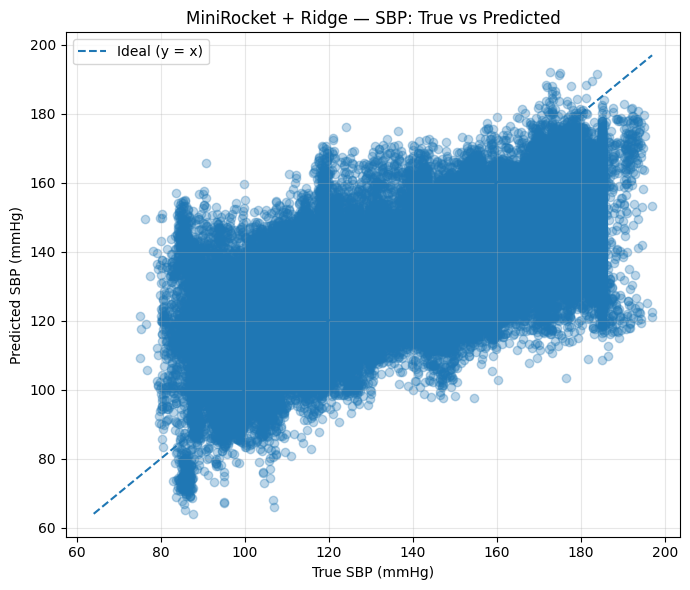

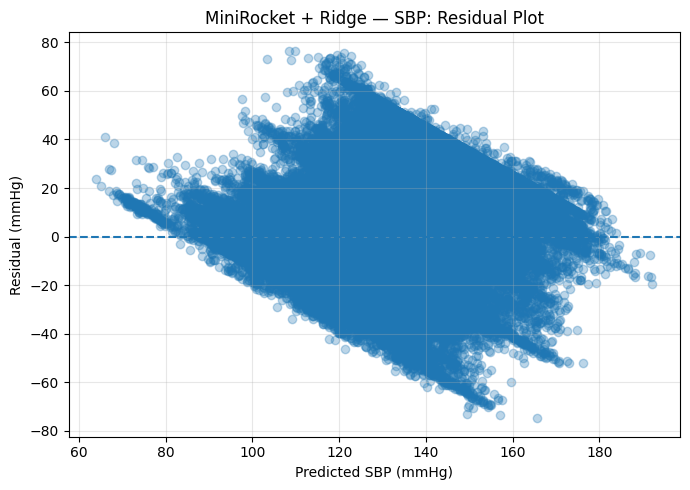

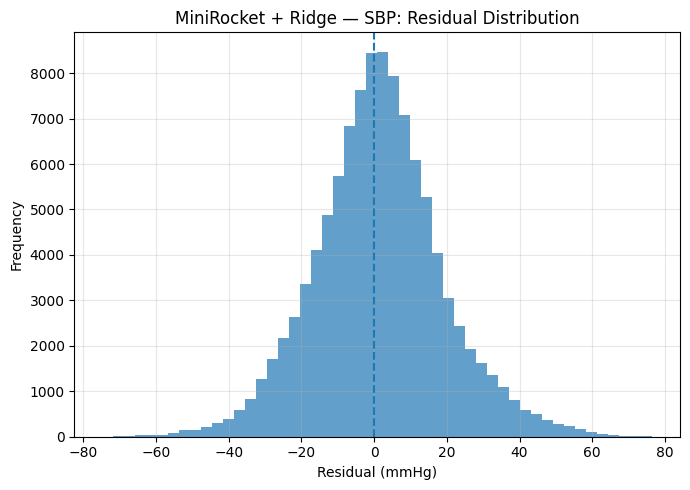

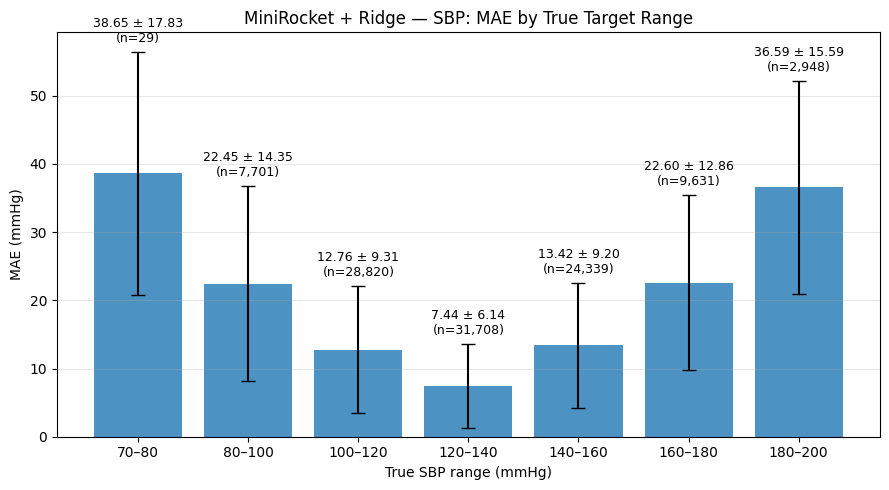

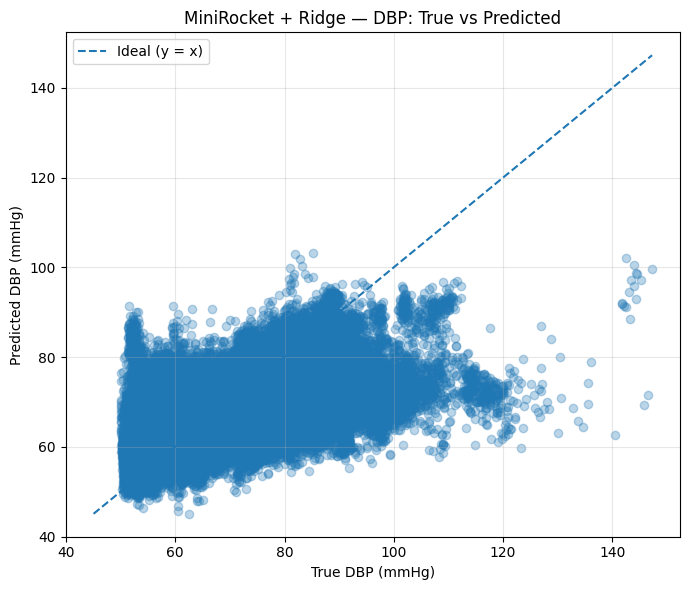

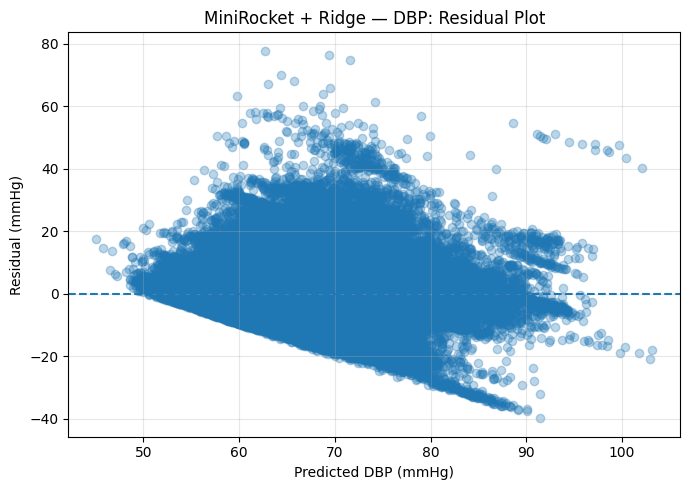

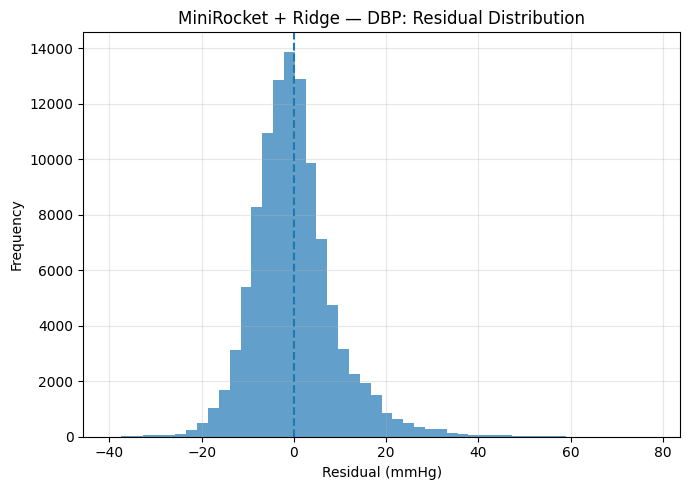

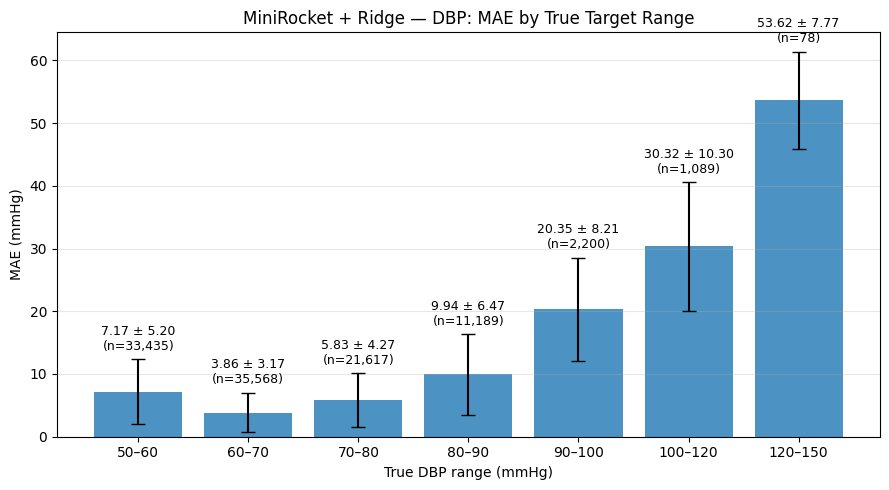

In [12]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1963


MiniROCKET VitalDB prediction: 100%|██████████| 1963/1963 [1:13:54<00:00,  2.26s/case]




MiniROCKET + Ridge
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 24.3032
MSE : 590.6444
R²  : -0.3819
MAE : 18.7943

DBP
------------------------------
RMSE: 14.1484
MSE : 200.1777
R²  : -0.2325
MAE : 11.0353


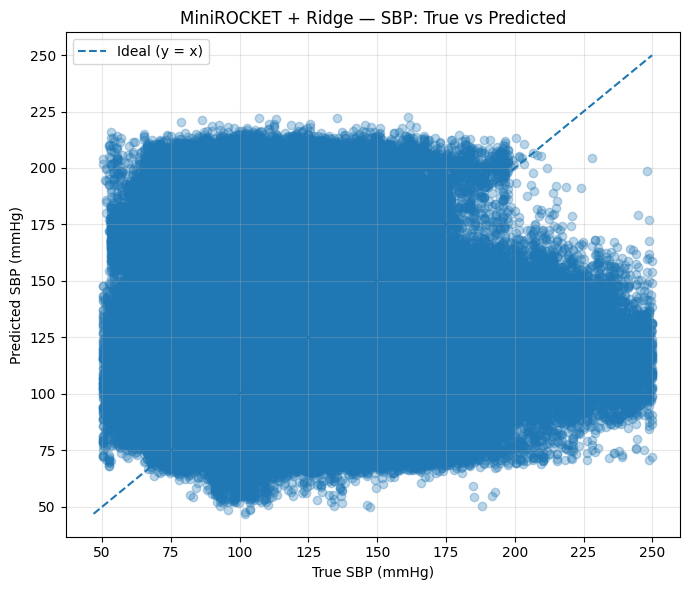

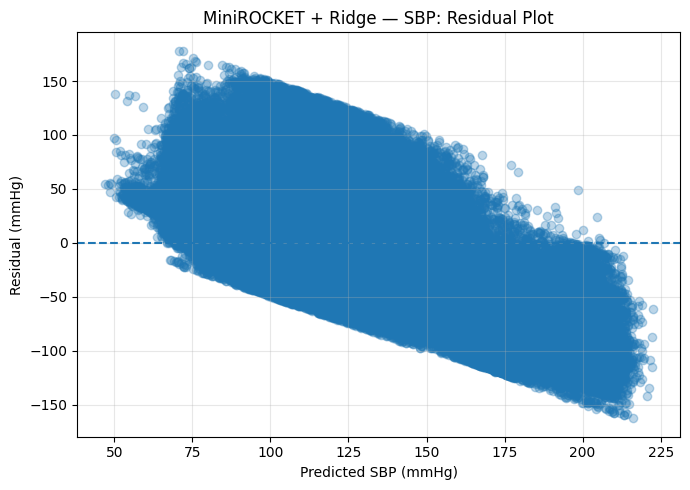

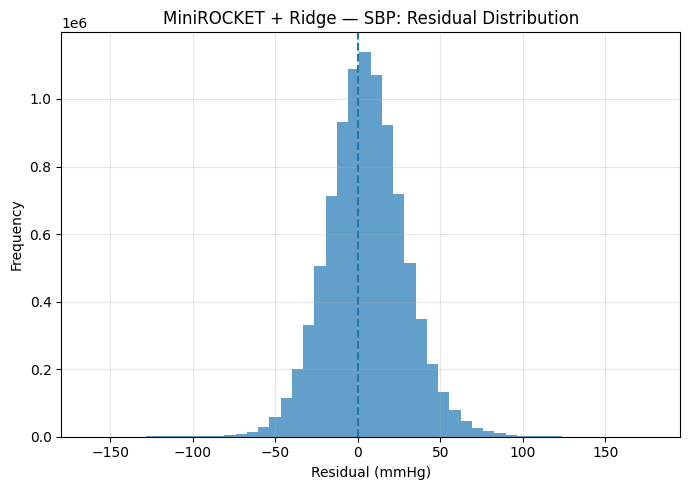

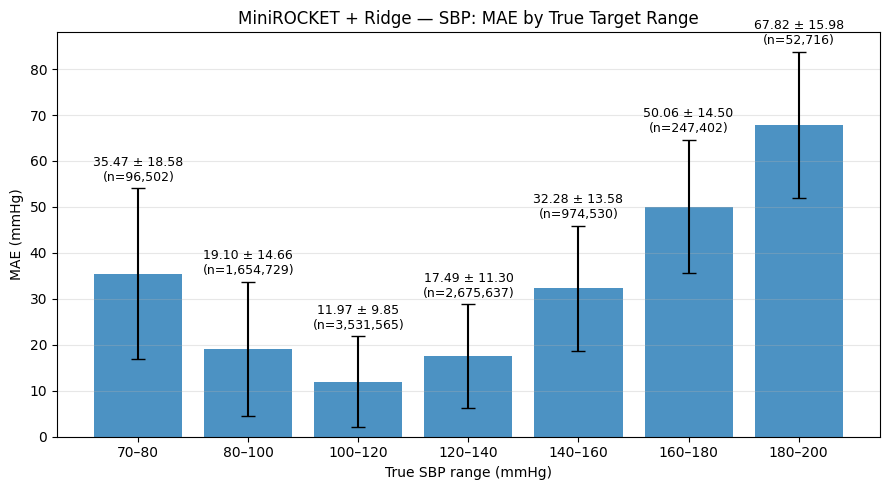

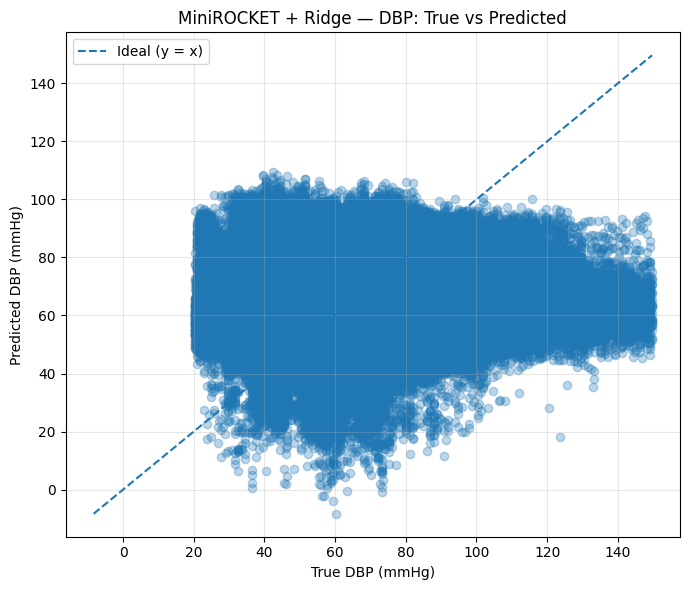

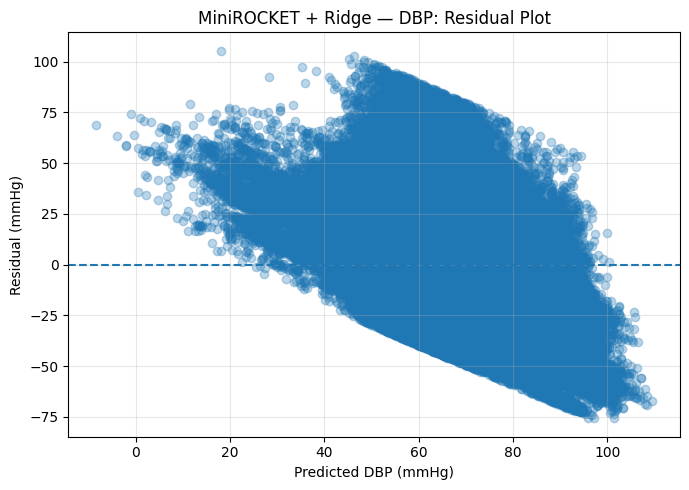

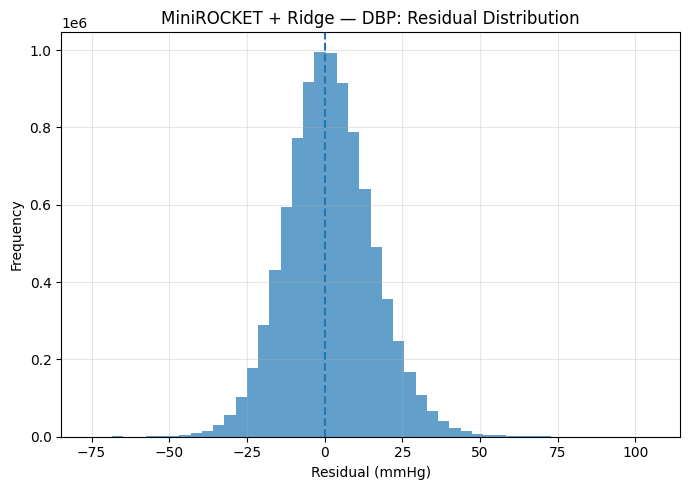

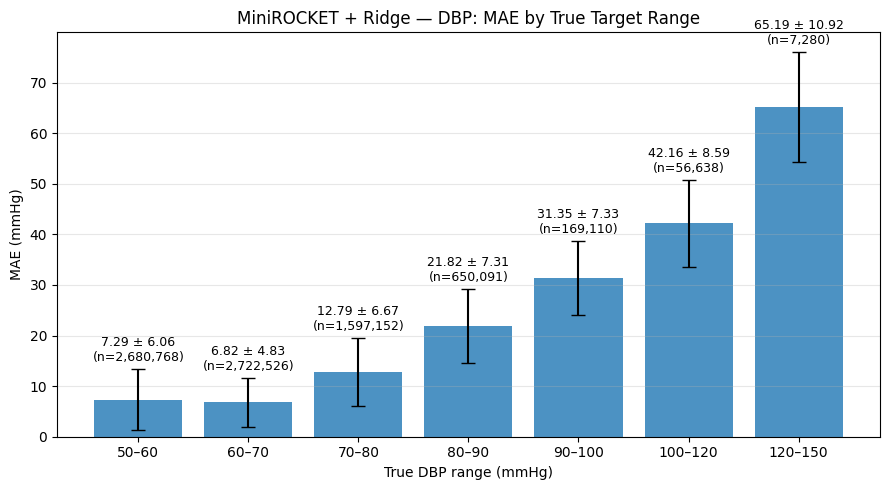


Final prediction shape:
(9271840, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  172.388672  119.588638  72.161774  51.714424
1  case_1  171.894928  118.938065  75.124176  50.504871
2  case_1  169.920013  113.449165  76.111603  53.304459
3  case_1  169.920013  114.332993  76.605347  54.417465
4  case_1  168.932587  120.317642  77.099091  53.122841


In [14]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    model = "Ridge",
    batch_size=5000
)

## MLP ##

In [15]:
mlp_sbp, mlp_dbp = train_mlp(X_train_rocket, y_train, X_val_rocket, y_val)

epoch 00 | TRAIN loss 0.2148 MSE(SBP 230.24, DBP 65.81) RMSE(SBP 15.17, DBP 8.11) | VAL loss 0.2538 MSE(SBP 283.85, DBP 74.69) RMSE(SBP 16.85, DBP 8.64)


epoch 01 | TRAIN loss 0.1812 MSE(SBP 186.80, DBP 56.26) RMSE(SBP 13.67, DBP 7.50) | VAL loss 0.2403 MSE(SBP 257.81, DBP 72.21) RMSE(SBP 16.06, DBP 8.50)


epoch 02 | TRAIN loss 0.1601 MSE(SBP 161.51, DBP 50.26) RMSE(SBP 12.71, DBP 7.09) | VAL loss 0.2291 MSE(SBP 240.80, DBP 69.15) RMSE(SBP 15.52, DBP 8.32)


epoch 03 | TRAIN loss 0.1499 MSE(SBP 151.06, DBP 47.05) RMSE(SBP 12.29, DBP 6.86) | VAL loss 0.2240 MSE(SBP 234.20, DBP 68.98) RMSE(SBP 15.30, DBP 8.31)


epoch 04 | TRAIN loss 0.1413 MSE(SBP 141.45, DBP 44.19) RMSE(SBP 11.89, DBP 6.65) | VAL loss 0.2191 MSE(SBP 233.72, DBP 65.79) RMSE(SBP 15.29, DBP 8.11)


...

epoch 25 | TRAIN loss 0.0871 MSE(SBP 82.41, DBP 27.87) RMSE(SBP 9.08, DBP 5.28) | VAL loss 0.1984 MSE(SBP 205.51, DBP 61.60) RMSE(SBP 14.34, DBP 7.85)


epoch 26 | TRAIN loss 0.0834 MSE(SBP 78.39, DBP 26.96) RMSE(SBP 8.85, DBP 5.19) | VAL loss 0.1958 MSE(SBP 201.95, DBP 61.18) RMSE(SBP 14.21, DBP 7.82)


epoch 27 | TRAIN loss 0.0831 MSE(SBP 78.17, DBP 26.83) RMSE(SBP 8.84, DBP 5.18) | VAL loss 0.1959 MSE(SBP 202.72, DBP 60.96) RMSE(SBP 14.24, DBP 7.81)


epoch 28 | TRAIN loss 0.0824 MSE(SBP 77.55, DBP 26.54) RMSE(SBP 8.81, DBP 5.15) | VAL loss 0.1964 MSE(SBP 204.91, DBP 61.01) RMSE(SBP 14.31, DBP 7.81)


epoch 29 | TRAIN loss 0.0816 MSE(SBP 76.67, DBP 26.29) RMSE(SBP 8.76, DBP 5.13) | VAL loss 0.1975 MSE(SBP 203.60, DBP 61.91) RMSE(SBP 14.27, DBP 7.87)


In [16]:
y_pred_sbp = batch_predict(mlp_sbp, X_test_rocket)
y_pred_dbp = batch_predict(mlp_dbp, X_test_rocket)
print_metrics(y_test[:, 0], y_pred_sbp)
print_metrics(y_test[:, 1], y_pred_dbp)

RMSE: 15.4688
MSE : 239.2847
R²  : 0.5467
MAE : 10.6493
RMSE: 8.1131
MSE : 65.8218
R²  : 0.4742
MAE : 5.3401


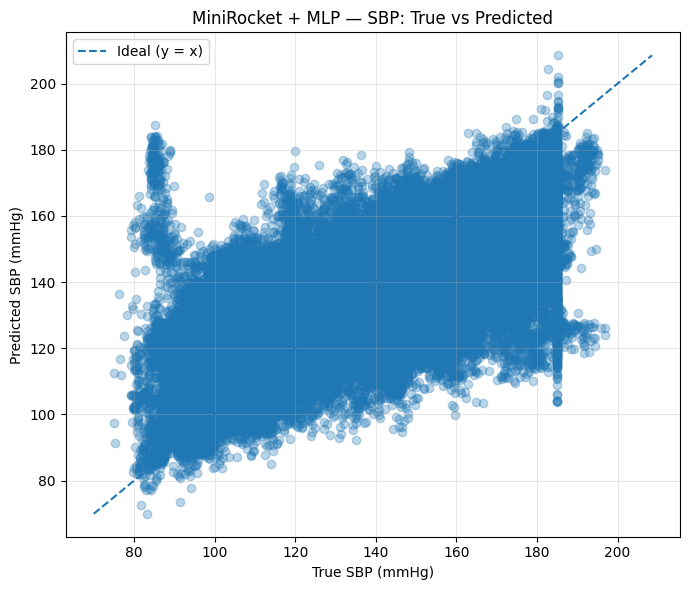

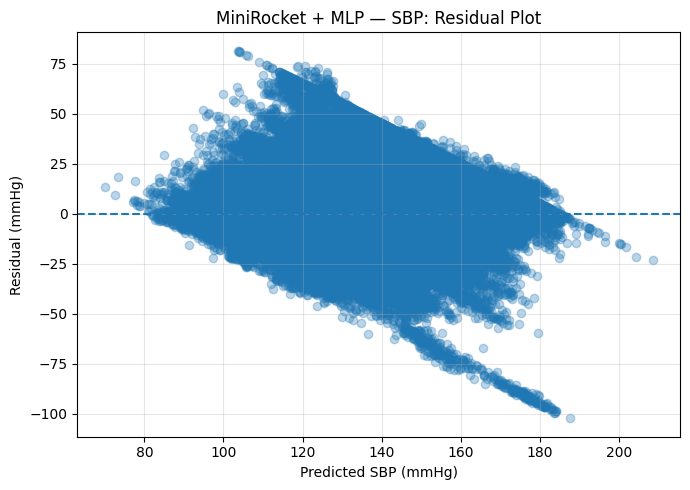

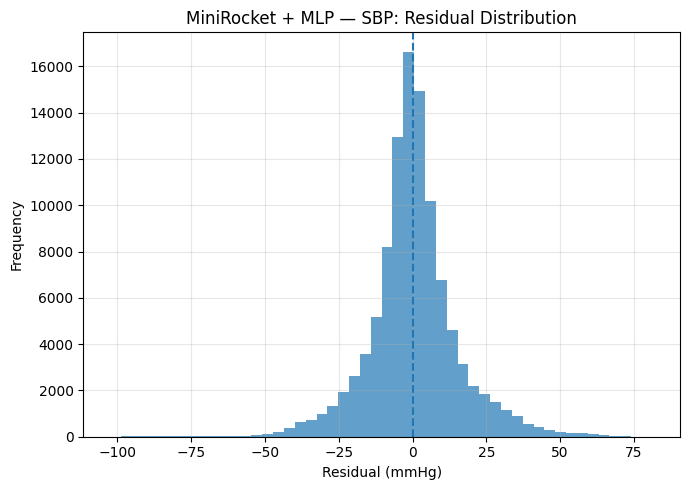

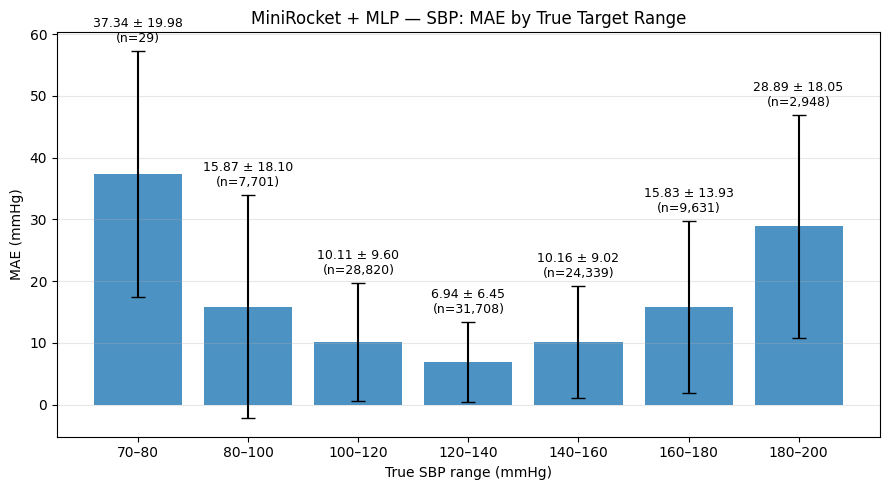

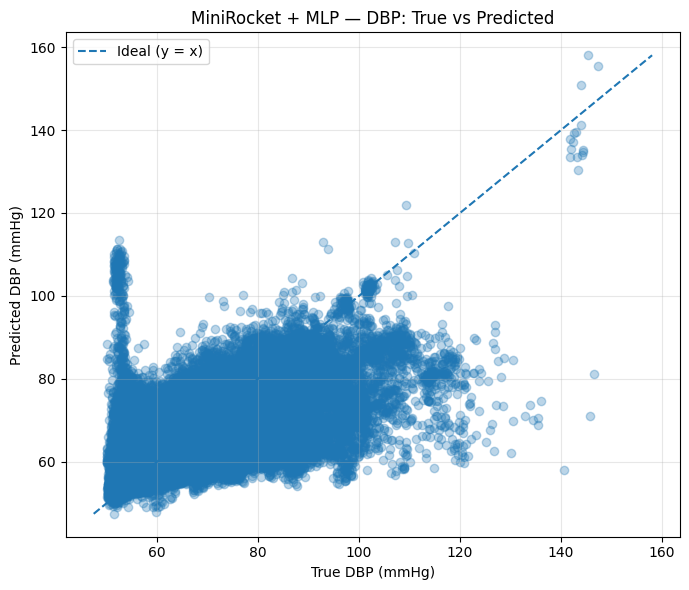

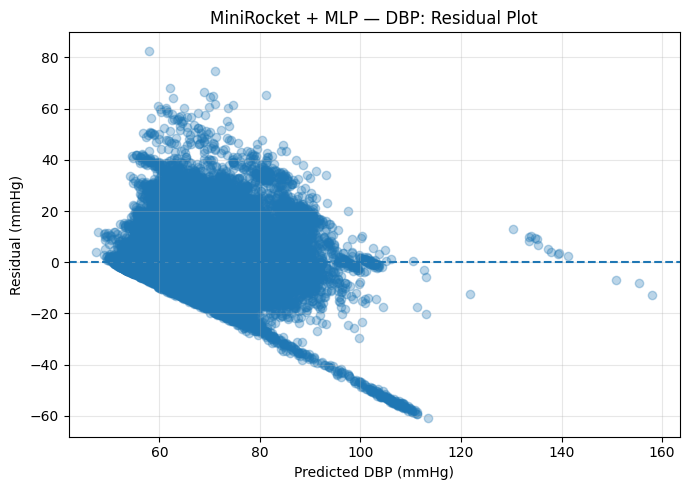

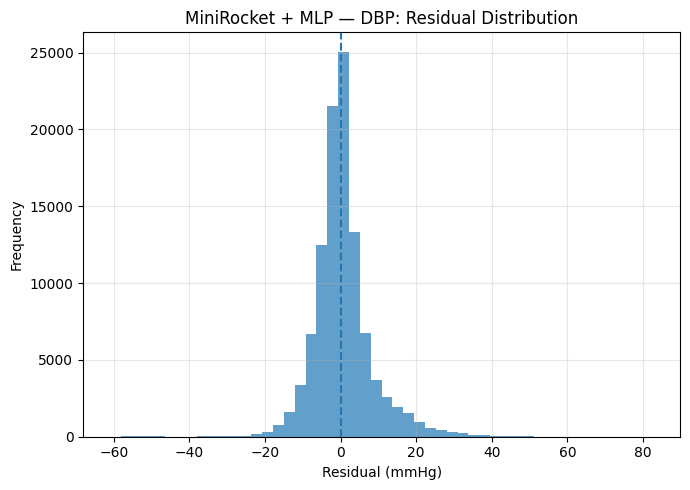

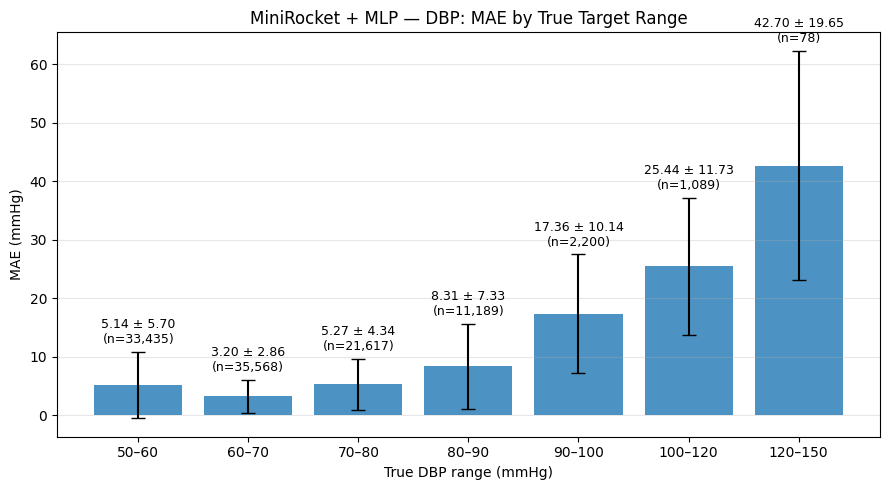

In [17]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + MLP",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + MLP",
    "DBP"
)

Number of VitalDB cases: 1963


MiniROCKET VitalDB prediction: 100%|██████████| 1963/1963 [1:13:43<00:00,  2.25s/case]




MiniROCKET + MLP
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 23.7154
MSE : 562.4197
R²  : -0.3159
MAE : 19.0696

DBP
------------------------------
RMSE: 12.9338
MSE : 167.2835
R²  : -0.0300
MAE : 10.2693


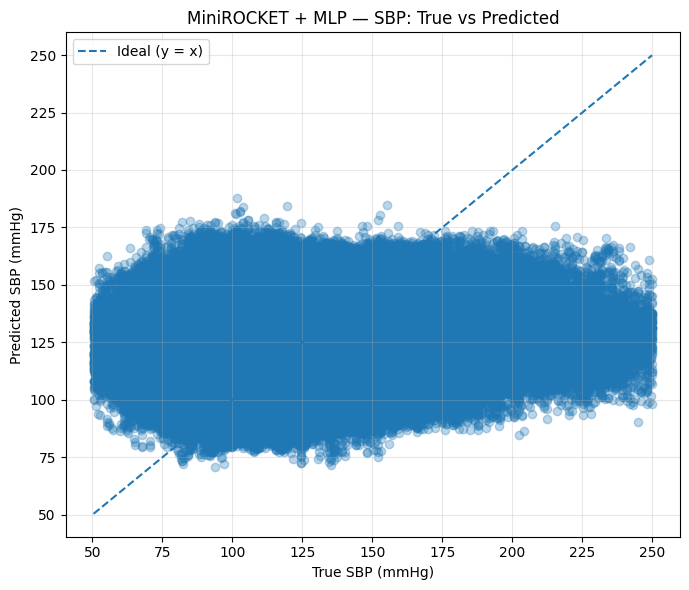

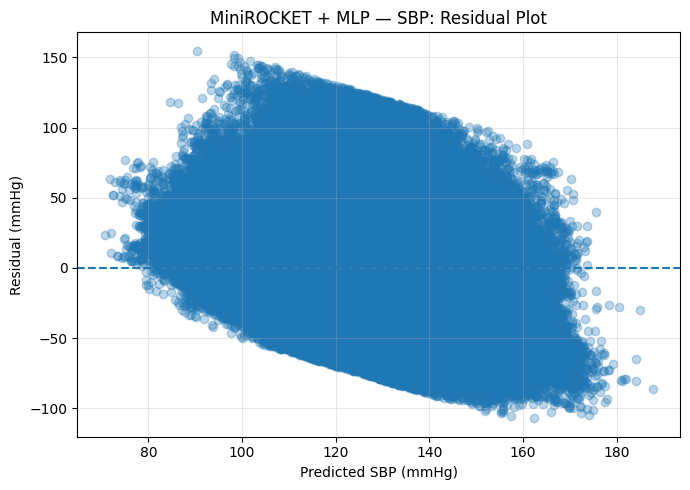

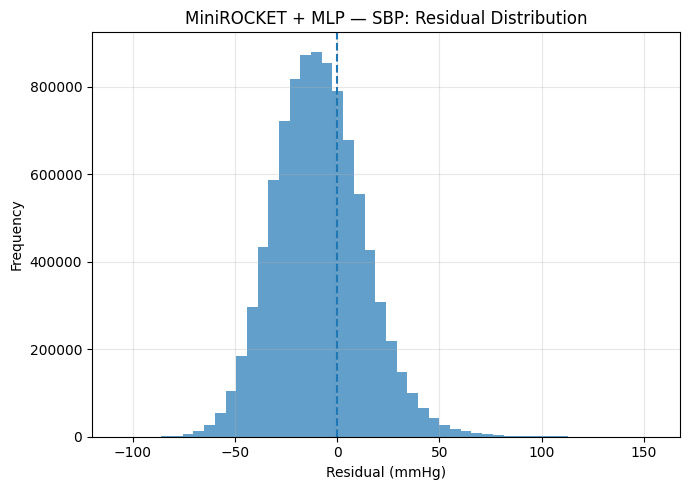

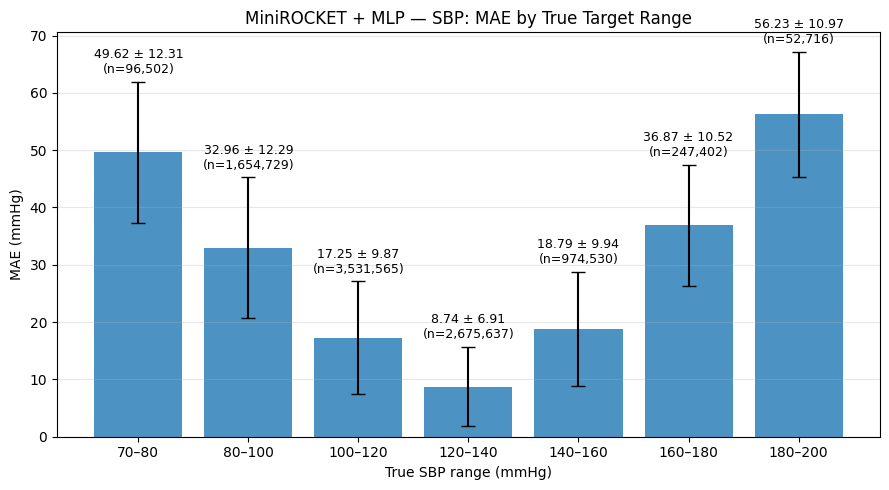

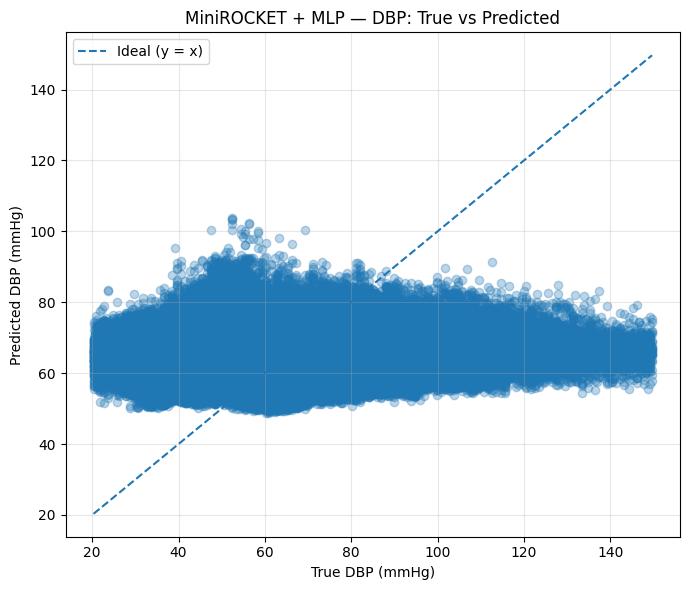

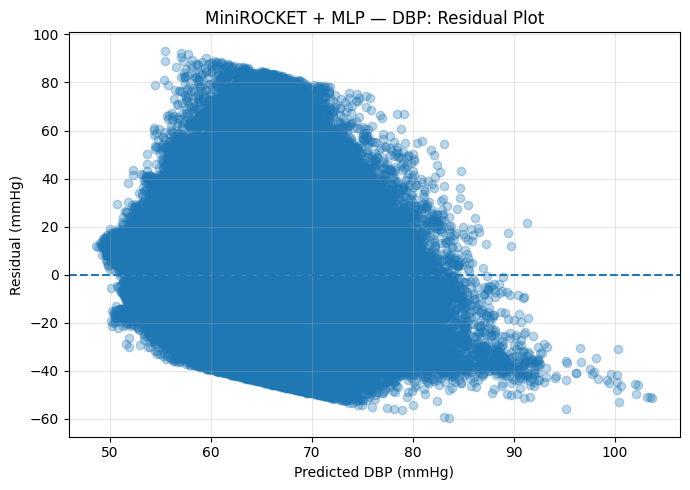

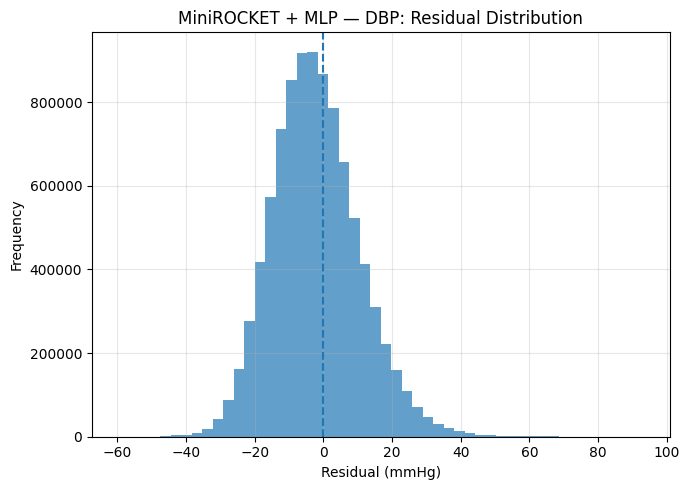

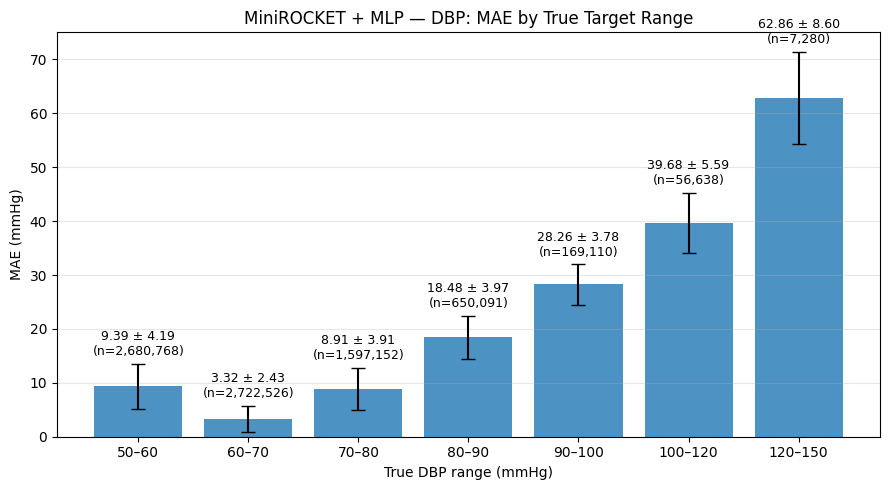


Final prediction shape:
(9271840, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  172.388672  125.402153  72.161774  65.306061
1  case_1  171.894928  125.733536  75.124176  64.477280
2  case_1  169.920013  126.619331  76.111603  64.815491
3  case_1  169.920013  125.054092  76.605347  64.210609
4  case_1  168.932587  124.103188  77.099091  64.611641


In [18]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR, rocket=rocket,
    best_en_sbp=mlp_sbp, best_en_dbp=mlp_dbp, model = "MLP", batch_size=2000)

## Feature Selection ##

In [19]:
sbp_idx, sbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 0],
    k=1000
)

dbp_idx, dbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 1],
    k=1000
)

In [20]:
print("SBP top features:", sbp_idx[:20])
print("SBP correlations:", sbp_corr[:20])

print("DBP top features:", dbp_idx[:20])
print("DBP correlations:", dbp_corr[:20])

SBP top features: [ 435  235  385 1005  254  230 1145  501  243  264  527 1788  972  272
  256 1103 1899 1450  404  217]
SBP correlations: [ 0.24481574 -0.24246639 -0.24027236 -0.23933442 -0.23654583 -0.23550513
  0.23540695  0.23438136 -0.23414506 -0.2340862   0.23363669 -0.23292948
  0.23273653 -0.23268458 -0.23172744  0.23055     0.22956425 -0.22927175
  0.22912933 -0.22898556]
DBP top features: [2102 1555 1157 1072  234  644  521  555  437  213 1847  980 1102 1496
  383  529  526 1170  239  550]
DBP correlations: [ 0.2382577   0.22458424  0.22308747 -0.21929054 -0.21731451  0.21616702
  0.21583875  0.2133948   0.21251051 -0.21114412 -0.20714456 -0.20670742
  0.20612599 -0.20542999 -0.20484932  0.20313413  0.20228189  0.2016728
 -0.20043953  0.19845018]
